# Ablation Study 1: NoFilter + VideoRoPE 2D + Local-Global CA

Ba bien the:
1. **NoFilter + VideoRoPE 2D (L=2)**: bo adaptive filtering, dung VideoRoPE 2D (temporal LTA + spatial axial 4x4).
2. **NoFilter + VideoRoPE 2D (L=4)**: nhu tren nhung tang so fusion block tu 2 -> 4.
3. **NoFilter + VideoRoPE 2D + Local-Global CA (L=2)**: thay full cross-attention bang two-stream Local-Global CA.
   - **Local stream**: cross-attn voi window mask `|t_seg - t_frame| <= W` giay, giu du 16 regions/frame de bat chyron, banner.
   - **Global stream**: nen N frames x 16 regions thanh G=16 global tokens (mean-pool theo region position xuyen thoi gian), giu layout 4x4 nhung bo truc thoi gian.
   - Hai stream cong lai; sigmoid gate per-head per-dim trong moi attention dieu chinh trong so.
   - Chi phi ~30-40% full CA, inductive bias manh hon cho video ban tin 60-120s.


In [3]:
import gc
import json
import math
import os
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup

cwd = Path.cwd().resolve()
# BASE_DIR = Path('/media/urlab/KINGSTON/aic')
BASE_DIR = Path('D:/aic')
SOURCE_DIR = BASE_DIR / 'source'
sys.path.insert(0, str(SOURCE_DIR / 'train'))
sys.path.insert(0, str(SOURCE_DIR / 'model'))
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('BASE_DIR:', BASE_DIR)
print('DEVICE  :', DEVICE)
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))


ImportError: cannot import name 'package' from partially initialized module 'torch' (most likely due to a circular import) (c:\ana\anaconda3\envs\ai_env\Lib\site-packages\torch\__init__.py)

In [ ]:
from dataset import get_dataloader
from model import (
    FusionEncoder,
    FusionBlock,
    GatedAttention,
    GatedAttentionVideoRoPE,
    RMSNorm,
    SwiGLUFFN,
    VideoRoPE2D,
    FusionBlockVideoRoPE,
    FusionBlockLocalGlobal,
    FusionEncoderNoFilterVideoRoPE,
    FusionEncoderNoFilterVideoRoPELG,
    build_fusion_encoder,
    FusionConfig,
)

ABLATION_OUTPUT = SOURCE_DIR / 'ablation_output'
ABLATION_OUTPUT.mkdir(parents=True, exist_ok=True)

BGEM3_PATH = BASE_DIR / 'data' / 'features' / 'weights' / 'bgem3'

CFG = {
    'base_dir': BASE_DIR,
    'max_frames': 25,
    'max_segments': 15,
    'max_seg_tokens': 128,
    'dim': 1024,
    'vis_dim': 1152,
    'n_heads': 16,
    'n_kv_heads': 4,
    'epochs': 75,
    'batch_size': 2,
    'grad_accum_steps': 8,
    'num_workers': os.cpu_count() or 4,
    'lr': 1e-4,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    'grad_clip': 1.0,
    'train_query_max_length': 512,
    'dual_softmax_tau': 0.01,
    'eval_query_max_length': 256,
    'eval_query_batch_size': 16,
    'visual_feature_subdir': 'siglip2',
    # VideoRoPE config
    'rope_base_temporal': 500_000.0,
    'rope_base_spatial': 10_000.0,
    'delta': 100.0,
    # Local-Global CA config
    'lg_window_seconds': 8.0,
    'lg_n_global_tokens': 16,
}
print('Output dir :', ABLATION_OUTPUT)


In [3]:
train_loader = get_dataloader(
    split='train', base_dir=CFG['base_dir'],
    batch_size=CFG['batch_size'], num_workers=CFG['num_workers'],
    max_frames=CFG['max_frames'], max_segments=CFG['max_segments'],
    max_seg_tokens=CFG['max_seg_tokens'],
    visual_feature_subdir=CFG['visual_feature_subdir'],
)
val_loader = get_dataloader(
    split='val', base_dir=CFG['base_dir'],
    batch_size=CFG['batch_size'], num_workers=CFG['num_workers'],
    max_frames=CFG['max_frames'], max_segments=CFG['max_segments'],
    max_seg_tokens=CFG['max_seg_tokens'],
    visual_feature_subdir=CFG['visual_feature_subdir'],
)

bgem3_tokenizer = AutoTokenizer.from_pretrained(str(BGEM3_PATH), local_files_only=True)
bgem3_model = AutoModel.from_pretrained(str(BGEM3_PATH), local_files_only=True)
bgem3_model.eval().to(DEVICE)
for p in bgem3_model.parameters():
    p.requires_grad = False

print('Train samples:', len(train_loader.dataset))
print('Val   samples:', len(val_loader.dataset))


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1160.96it/s]


Train samples: 6150
Val   samples: 6156


## VideoRoPE 2D module

Tách head_dim = 64 thành 3 nhóm:
- `n_t = 32` (50% — temporal, low-freq base 500k cho LTA)
- `n_r = 16` (25% — spatial row, high-freq base 10k)
- `n_c = 16` (25% — spatial col, high-freq base 10k)


In [ ]:
# VideoRoPE2D and GatedAttentionVideoRoPE are now imported from `model` package
# (see source/model/components.py and source/model/attention.py).
print('Imported: VideoRoPE2D, GatedAttentionVideoRoPE')


In [ ]:
# FusionBlockVideoRoPE and FusionEncoderNoFilterVideoRoPE are now imported from
# the modular `model` package (source/model/blocks.py, source/model/fusion_encoder.py).
print('Imported: FusionBlockVideoRoPE, FusionEncoderNoFilterVideoRoPE')


## Training & evaluation utilities

In [6]:
def encode_queries(texts, tokenizer, encoder_model, device, max_length=512, batch_size=None):
    if not texts:
        return torch.empty((0, encoder_model.config.hidden_size), device=device)
    if batch_size is None:
        batch_size = len(texts)
    all_embs = []
    with torch.inference_mode():
        for start in range(0, len(texts), batch_size):
            chunk = texts[start:start + batch_size]
            enc = tokenizer(chunk, padding=True, truncation=True,
                            max_length=max_length, return_tensors='pt').to(device)
            if device.type == 'cuda':
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    h = encoder_model(**enc, return_dict=True).last_hidden_state
            else:
                h = encoder_model(**enc, return_dict=True).last_hidden_state
            m = enc['attention_mask'].unsqueeze(-1).to(h.dtype)
            pooled = (h * m).sum(1) / m.sum(1).clamp_min(1e-6)
            all_embs.append(F.normalize(pooled.float(), p=2, dim=-1))
    return torch.cat(all_embs, dim=0)


def symmetric_infonce(q, d, temperature):
    tau = torch.exp(temperature).clamp_min(1e-6)
    sim = torch.matmul(q, d.T) / tau
    labels = torch.arange(sim.size(0), device=sim.device)
    return 0.5 * (F.cross_entropy(sim, labels) + F.cross_entropy(sim.T, labels))


def retrieval_loss(q_hat, e_plus, e_narr, temperature, hard_neg_embs=None,
                   lambda_narr=0.5, beta_hard=0.3, gamma_mrl=0.1):
    l_base = symmetric_infonce(q_hat, e_plus, temperature)
    l_narr = torch.tensor(0.0, device=q_hat.device)
    if lambda_narr > 0:
        l_narr = symmetric_infonce(q_hat, e_narr, temperature)
    l_hard = torch.tensor(0.0, device=q_hat.device)
    if hard_neg_embs is not None and beta_hard > 0:
        q = q_hat.unsqueeze(1)
        neg_scores = torch.sum(q * hard_neg_embs, dim=-1)
        pos_scores = torch.sum(q_hat * e_plus, dim=-1, keepdim=True)
        l_hard = torch.relu(neg_scores - pos_scores + 0.1).mean()
    l_mrl = torch.tensor(0.0, device=q_hat.device)
    if gamma_mrl > 0:
        for d_dim in [64, 128, 256, 512, 1024]:
            l_mrl = l_mrl + symmetric_infonce(q_hat[:, :d_dim], e_plus[:, :d_dim], temperature)
        l_mrl = l_mrl / 5.0
    return l_base + lambda_narr * l_narr + beta_hard * l_hard + gamma_mrl * l_mrl


def _encode_hard_negs(hard_neg_texts_batch, max_length):
    b = len(hard_neg_texts_batch)
    k = max((len(x) for x in hard_neg_texts_batch), default=0)
    if k == 0:
        return None
    flat = []
    for negs in hard_neg_texts_batch:
        flat.extend(negs + [''] * (k - len(negs)))
    emb = encode_queries(flat, bgem3_tokenizer, bgem3_model, DEVICE, max_length=max_length)
    return emb.view(b, k, -1)


def precompute_val_docs(model, loader, device):
    model.eval()
    doc_embs, shot_ids = [], []
    with torch.inference_mode():
        for batch in tqdm(loader, desc='Val docs', leave=False, dynamic_ncols=True):
            with torch.amp.autocast(device_type='cuda' if device.type == 'cuda' else 'cpu',
                                   enabled=(device.type == 'cuda'), dtype=torch.bfloat16):
                e_plus, _, _ = model(
                    seg_tokens=batch['token_reprs'].to(device),
                    seg_pooled=batch['segment_pooled'].to(device),
                    visual_features=batch['visual_features'].to(device),
                    seg_timestamps=batch['seg_timestamps'].to(device),
                    frame_timestamps=batch['frame_timestamps'].to(device),
                    seg_mask=batch['segment_mask'].to(device),
                    visual_mask=batch['visual_mask'].to(device),
                    query_emb=None,
                    token_mask=batch['token_mask'].to(device),
                )
            doc_embs.append(e_plus.detach().cpu())
            shot_ids.extend(batch['shot_id'])
    return F.normalize(torch.cat(doc_embs, dim=0), p=2, dim=-1), shot_ids


def load_val_queries():
    q_items = []
    for jf in sorted((BASE_DIR / 'data' / 'val').glob('*.json')):
        video_id = jf.stem
        for row in json.loads(jf.read_text('utf-8')):
            sid = str(row.get('id', '')).zfill(3)
            q = str(row.get('positive', '')).strip()
            if sid and q:
                q_items.append({'shot_id': f'{video_id}_{sid}', 'query': q})
    seen, deduped = set(), []
    for x in q_items:
        if x['shot_id'] not in seen:
            seen.add(x['shot_id'])
            deduped.append(x)
    return deduped


def evaluate_on_val(model, device):
    doc_embs, shot_ids = precompute_val_docs(model, val_loader, device)
    q_items = load_val_queries()
    q_embs_all = encode_queries(
        [x['query'] for x in q_items],
        bgem3_tokenizer, bgem3_model, device,
        max_length=CFG['eval_query_max_length'],
        batch_size=CFG['eval_query_batch_size'],
    )
    shot_to_idx = {s: i for i, s in enumerate(shot_ids)}
    filtered = [x for x in q_items if x['shot_id'] in shot_to_idx]
    q_idx = [q_items.index(x) for x in filtered]
    q_embs_f = q_embs_all[q_idx]
    gt_indices = [shot_to_idx[x['shot_id']] for x in filtered]
    tau = CFG['dual_softmax_tau']
    sim_raw = torch.matmul(q_embs_f, doc_embs.to(device).T) / tau
    sim_dsl = torch.softmax(sim_raw, dim=1) * torch.softmax(sim_raw, dim=0)
    sim_np = sim_dsl.detach().cpu().numpy()
    ranks = [int(np.where(np.argsort(-sim_np[i]) == gt)[0][0]) + 1
             for i, gt in enumerate(gt_indices)]
    ranks = np.array(ranks)
    return {
        'R1':  float((ranks <= 1).mean() * 100),
        'R5':  float((ranks <= 5).mean() * 100),
        'R10': float((ranks <= 10).mean() * 100),
        'SumR': float(((ranks <= 1).mean() + (ranks <= 5).mean() + (ranks <= 10).mean()) * 100),
        'MedR': float(np.median(ranks)),
        'MeanR': float(ranks.mean()),
        'n_queries': len(ranks),
    }


In [7]:
def run_variant(model_class, n_layers, ckpt_name, desc,
                loss_cfg=None, train_from_scratch=True, extra_arch=None):
    if loss_cfg is None:
        loss_cfg = dict(lambda_narr=0.5, beta_hard=0.3, gamma_mrl=0.1)

    arch = dict(
        dim=CFG['dim'], vis_dim=CFG['vis_dim'],
        n_layers=n_layers, n_heads=CFG['n_heads'], n_kv_heads=CFG['n_kv_heads'],
        delta=CFG['delta'],
        base_temporal=CFG['rope_base_temporal'],
        base_spatial=CFG['rope_base_spatial'],
    )
    if extra_arch:
        arch.update(extra_arch)
    model = model_class(**arch).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    accum_steps = max(1, int(CFG.get('grad_accum_steps', 1)))
    steps_per_epoch = math.ceil(len(train_loader) / accum_steps)
    total_steps = max(1, steps_per_epoch * CFG['epochs'])
    warmup_steps = int(total_steps * CFG['warmup_ratio'])
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler = torch.amp.GradScaler('cuda' if DEVICE.type == 'cuda' else 'cpu')

    ckpt_path = ABLATION_OUTPUT / ckpt_name
    last_path = ABLATION_OUTPUT / 'last.pt'
    log_path = ABLATION_OUTPUT / ckpt_name.replace('.pth', '_log.json')

    history = []
    start_epoch = 1
    best_r1 = -1.0

    if not train_from_scratch and ckpt_path.exists() and log_path.exists():
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        history = json.loads(log_path.read_text('utf-8'))
        start_epoch = (history[-1]['epoch'] + 1) if history else 1
        best_r1 = max((h.get('R1', -1.0) for h in history), default=-1.0)
        print(f'[{desc}] Resume from epoch {start_epoch}, best R1={best_r1:.2f}')

    print(f'[{desc}] params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M | L={n_layers}')

    for epoch in range(start_epoch, CFG['epochs'] + 1):
        model.train()
        running = 0.0
        pbar = tqdm(train_loader, desc=f'[{desc}] ep{epoch:02d}', leave=False, dynamic_ncols=True)
        optimizer.zero_grad(set_to_none=True)
        for step, batch in enumerate(pbar, start=1):
            q_hat = encode_queries(batch['query_text'], bgem3_tokenizer, bgem3_model, DEVICE,
                                    max_length=CFG['train_query_max_length'])
            hard_neg = _encode_hard_negs(batch['hard_neg_texts'], CFG['train_query_max_length'])

            visual_features = batch['visual_features'].to(DEVICE)
            visual_mask = batch['visual_mask'].to(DEVICE)
            frame_timestamps = batch['frame_timestamps'].to(DEVICE)
            token_reprs = batch['token_reprs'].to(DEVICE)
            token_mask = batch['token_mask'].to(DEVICE)
            segment_pooled = batch['segment_pooled'].to(DEVICE)
            segment_mask = batch['segment_mask'].to(DEVICE)
            seg_timestamps = batch['seg_timestamps'].to(DEVICE)

            with torch.amp.autocast(device_type='cuda' if DEVICE.type == 'cuda' else 'cpu',
                                   enabled=(DEVICE.type == 'cuda'), dtype=torch.bfloat16):
                e_plus, e_narr, temperature = model(
                    seg_tokens=token_reprs, seg_pooled=segment_pooled,
                    visual_features=visual_features,
                    seg_timestamps=seg_timestamps, frame_timestamps=frame_timestamps,
                    seg_mask=segment_mask, visual_mask=visual_mask,
                    query_emb=q_hat, token_mask=token_mask,
                )
                loss = retrieval_loss(q_hat, e_plus, e_narr, temperature,
                                      hard_neg_embs=hard_neg, **loss_cfg)

            loss_raw = loss.detach()
            loss = loss / accum_steps
            scaler.scale(loss).backward()

            if step % accum_steps == 0 or step == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
                scaler.step(optimizer)
                with torch.no_grad():
                    model.temperature.clamp_(min=math.log(0.01), max=math.log(1.0))
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            running += loss_raw.item()
            pbar.set_postfix(loss=f'{running / (pbar.n + 1):.4f}')

        train_loss = running / max(1, len(train_loader))

        if DEVICE.type == 'cuda':
            gc.collect(); torch.cuda.empty_cache()

        val_metrics = evaluate_on_val(model, DEVICE)
        history.append({'epoch': epoch, 'train_loss': train_loss, **val_metrics})

        if val_metrics['R1'] > best_r1:
            best_r1 = val_metrics['R1']
            torch.save(model.state_dict(), ckpt_path)
        torch.save(model.state_dict(), last_path)
        log_path.write_text(json.dumps(history, indent=2), encoding='utf-8')
        print(f"[{desc}] ep{epoch:02d} loss={train_loss:.4f} R@1={val_metrics['R1']:.2f} "
              f"R@5={val_metrics['R5']:.2f} R@10={val_metrics['R10']:.2f}")

    print(f'[{desc}] DONE | best R@1={best_r1:.2f} | ckpt={ckpt_path}')
    return history, best_r1


## Local-Global Cross-Attention module

**Local CA**: cross-attn segment Q x visual K/V voi mask cua so thoi gian `|t_seg - t_frame| <= W` giay.
Toan bo 16 regions/frame duoc giu - chi gioi han theo truc thoi gian.

**Global CA**: nen N frames x 16 regions -> G=16 global tokens bang mean-pool theo region position xuyen thoi gian (giu layout 4x4). Global tokens khong co temporal - chi dung spatial RoPE (t_pos=0).

**Combine**: `out = LocalCA(...) + GlobalCA(...)` - khong can gate ngoai vi moi attention da co sigmoid gate per-head per-dim san.


In [ ]:
# FusionBlockLocalGlobal and FusionEncoderNoFilterVideoRoPELG are now imported
# from the modular `model` package (Variant 3 = main model).
print('Imported: FusionBlockLocalGlobal, FusionEncoderNoFilterVideoRoPELG (MAIN)')


## Variant 1: NoFilter + VideoRoPE 2D, L=2

In [9]:
history_v1, best_r1_v1 = run_variant(
    model_class=FusionEncoderNoFilterVideoRoPE,
    n_layers=2,
    ckpt_name='ablation1_nofilter_videorope_L2.pth',
    desc='NoFilter+VideoRoPE-L2',
    train_from_scratch=False,
)


[NoFilter+VideoRoPE-L2] Resume from epoch 54, best R1=75.32
[NoFilter+VideoRoPE-L2] params: 45.22 M | L=2


[NoFilter+VideoRoPE-L2] ep54 loss=0.6479 R@1=68.10 R@5=84.42 R@10=88.48


[NoFilter+VideoRoPE-L2] ep55 loss=0.6423 R@1=67.35 R@5=84.36 R@10=88.71


[NoFilter+VideoRoPE-L2] ep56 loss=0.6315 R@1=68.11 R@5=85.06 R@10=89.25


[NoFilter+VideoRoPE-L2] ep57 loss=0.6250 R@1=68.49 R@5=85.54 R@10=89.38


KeyboardInterrupt: 

In [10]:
if 'test_loader' not in globals():
    test_loader = get_dataloader(
        split='test', base_dir=CFG['base_dir'],
        batch_size=CFG['batch_size'], num_workers=CFG['num_workers'],
        max_frames=CFG['max_frames'], max_segments=CFG['max_segments'],
        max_seg_tokens=CFG['max_seg_tokens'],
        visual_feature_subdir=CFG['visual_feature_subdir'],
    )


def _find_query_dir(split):
    candidates = [
        BASE_DIR / 'data' / split,
        BASE_DIR / 'data' / f'{split}2',
    ]
    for d in candidates:
        if d.exists() and any(d.glob('*.json')):
            return d
    raise FileNotFoundError(f'No query JSON found for split={split} in {candidates}')


def load_test_queries():
    q_items = []
    q_dir = _find_query_dir('test')
    for jf in sorted(q_dir.glob('*.json')):
        video_id = jf.stem
        for row in json.loads(jf.read_text('utf-8')):
            sid = str(row.get('id', '')).zfill(3)
            q = str(row.get('positive', '')).strip()
            if sid and q:
                q_items.append({'shot_id': f'{video_id}_{sid}', 'query': q})
    seen, deduped = set(), []
    for x in q_items:
        if x['shot_id'] not in seen:
            seen.add(x['shot_id'])
            deduped.append(x)
    return deduped


def evaluate_on_test(model, device):
    doc_embs, shot_ids = precompute_val_docs(model, test_loader, device)
    q_items = load_test_queries()
    q_embs_all = encode_queries(
        [x['query'] for x in q_items],
        bgem3_tokenizer, bgem3_model, device,
        max_length=CFG['eval_query_max_length'],
        batch_size=CFG['eval_query_batch_size'],
    )
    shot_to_idx = {s: i for i, s in enumerate(shot_ids)}
    filtered = [x for x in q_items if x['shot_id'] in shot_to_idx]
    q_idx = [q_items.index(x) for x in filtered]
    q_embs_f = q_embs_all[q_idx]
    gt_indices = [shot_to_idx[x['shot_id']] for x in filtered]
    tau = CFG['dual_softmax_tau']
    sim_raw = torch.matmul(q_embs_f, doc_embs.to(device).T) / tau
    sim_dsl = torch.softmax(sim_raw, dim=1) * torch.softmax(sim_raw, dim=0)
    sim_np = sim_dsl.detach().cpu().numpy()
    ranks = [int(np.where(np.argsort(-sim_np[i]) == gt)[0][0]) + 1
             for i, gt in enumerate(gt_indices)]
    ranks = np.array(ranks)
    return {
        'R1': float((ranks <= 1).mean() * 100),
        'R5': float((ranks <= 5).mean() * 100),
        'R10': float((ranks <= 10).mean() * 100),
        'SumR': float(((ranks <= 1).mean() + (ranks <= 5).mean() + (ranks <= 10).mean()) * 100),
        'MedR': float(np.median(ranks)),
        'MeanR': float(ranks.mean()),
        'n_queries': len(ranks),
    }


def _eval_ckpt(ckpt_path, tag):
    model = FusionEncoderNoFilterVideoRoPE(
        dim=CFG['dim'], vis_dim=CFG['vis_dim'],
        n_layers=2, n_heads=CFG['n_heads'], n_kv_heads=CFG['n_kv_heads'],
        delta=CFG['delta'],
        base_temporal=CFG['rope_base_temporal'],
        base_spatial=CFG['rope_base_spatial'],
    ).to(DEVICE)
    state = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state)
    metrics = evaluate_on_test(model, DEVICE)
    print(f"{tag} | R@1={metrics['R1']:.2f} R@5={metrics['R5']:.2f} "
          f"R@10={metrics['R10']:.2f} SumR={metrics['SumR']:.2f}")
    return metrics


best_ckpt_v1 = ABLATION_OUTPUT / 'ablation1_nofilter_videorope_L2.pth'
last_ckpt = ABLATION_OUTPUT / 'last.pt'

best_test_v1 = _eval_ckpt(best_ckpt_v1, 'Variant1-BEST')
last_test_v1 = _eval_ckpt(last_ckpt, 'Variant1-LAST')


Val docs:   0%|          | 0/3092 [00:00<?, ?it/s]

Variant1-BEST | R@1=72.18 R@5=87.21 R@10=90.60 SumR=249.99


Variant1-BEST | R@1=72.18 R@5=87.21 R@10=90.60 SumR=249.99


Variant1-BEST | R@1=72.18 R@5=87.21 R@10=90.60 SumR=249.99


Variant1-LAST | R@1=73.09 R@5=88.45 R@10=91.48 SumR=253.02


## Variant 2: NoFilter + VideoRoPE 2D, L=4

In [ ]:
history_v2, best_r1_v2 = run_variant(
    model_class=FusionEncoderNoFilterVideoRoPE,
    n_layers=4,
    ckpt_name='ablation1_nofilter_videorope_L4.pth',
    desc='NoFilter+VideoRoPE-L4',
    train_from_scratch=True,
)


[NoFilter+VideoRoPE-L4] params: 89.27 M | L=4


KeyboardInterrupt: 

## Variant 3: NoFilter + VideoRoPE 2D + Local-Global CA, L=2


In [ ]:
history_v3, best_r1_v3 = run_variant(
    model_class=FusionEncoderNoFilterVideoRoPELG,
    n_layers=2,
    ckpt_name='ablation1_nofilter_videorope_lg_L2.pth',
    desc='NoFilter+VideoRoPE+LG-L2',
    train_from_scratch=True,
    extra_arch=dict(
        window_seconds=CFG['lg_window_seconds'],
        n_global_tokens=CFG['lg_n_global_tokens'],
    ),
)


[NoFilter+VideoRoPE+LG-L2] params: 50.47 M | L=2


[NoFilter+VideoRoPE+LG-L2] ep01 loss=1.0580 R@1=25.63 R@5=45.38 R@10=54.30


[NoFilter+VideoRoPE+LG-L2] ep02 loss=1.0091 R@1=30.77 R@5=52.30 R@10=61.55


[NoFilter+VideoRoPE+LG-L2] ep03 loss=0.9886 R@1=37.29 R@5=60.45 R@10=69.11


[NoFilter+VideoRoPE+LG-L2] ep04 loss=0.9687 R@1=42.60 R@5=66.12 R@10=74.18


...

[NoFilter+VideoRoPE+LG-L2] ep26 loss=0.6739 R@1=73.21 R@5=89.11 R@10=92.93


[NoFilter+VideoRoPE+LG-L2] ep27 loss=0.6723 R@1=73.36 R@5=89.19 R@10=92.90


[NoFilter+VideoRoPE+LG-L2] ep28 loss=0.6696 R@1=73.30 R@5=89.31 R@10=92.90


[NoFilter+VideoRoPE+LG-L2] ep29 loss=0.6692 R@1=73.26 R@5=89.32 R@10=92.89


[NoFilter+VideoRoPE+LG-L2] ep30 loss=0.6690 R@1=73.27 R@5=89.33 R@10=92.89
[NoFilter+VideoRoPE+LG-L2] DONE | best R@1=73.36 | ckpt=/media/urlab/KINGSTON/aic/source/ablation_output/ablation1_nofilter_videorope_lg_L2.pth


In [11]:
def _eval_ckpt_v3(ckpt_path, tag):
    model = FusionEncoderNoFilterVideoRoPELG(
        dim=CFG['dim'], vis_dim=CFG['vis_dim'],
        n_layers=2, n_heads=CFG['n_heads'], n_kv_heads=CFG['n_kv_heads'],
        delta=CFG['delta'],
        base_temporal=CFG['rope_base_temporal'],
        base_spatial=CFG['rope_base_spatial'],
        window_seconds=CFG['lg_window_seconds'],
        n_global_tokens=CFG['lg_n_global_tokens'],
    ).to(DEVICE)
    state = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state)
    metrics = evaluate_on_test(model, DEVICE)
    print(f"{tag} | R@1={metrics['R1']:.2f} R@5={metrics['R5']:.2f} "
          f"R@10={metrics['R10']:.2f} SumR={metrics['SumR']:.2f}")
    return metrics


best_ckpt_v3 = ABLATION_OUTPUT / 'ablation1_nofilter_videorope_lg_L2.pth'
best_test_v3 = _eval_ckpt_v3(best_ckpt_v3, 'Variant3-BEST')


Variant3-BEST | R@1=73.57 R@5=88.08 R@10=91.15 SumR=252.81


In [ ]:
# Resume Variant 3 from checkpoint
history_v3, best_r1_v3 = run_variant(
    model_class=FusionEncoderNoFilterVideoRoPELG,
    n_layers=2,
    ckpt_name='ablation1_nofilter_videorope_lg_L2.pth',
    desc='NoFilter+VideoRoPE+LG-L2',
    train_from_scratch=False,
    extra_arch=dict(
        window_seconds=CFG['lg_window_seconds'],
        n_global_tokens=CFG['lg_n_global_tokens'],
    ),
)


[NoFilter+VideoRoPE+LG-L2] Resume from epoch 31, best R1=73.36
[NoFilter+VideoRoPE+LG-L2] params: 50.47 M | L=2


[NoFilter+VideoRoPE+LG-L2] ep31 loss=0.6712 R@1=73.05 R@5=89.30 R@10=92.92


[NoFilter+VideoRoPE+LG-L2] ep32 loss=0.6677 R@1=73.19 R@5=89.17 R@10=92.95


[NoFilter+VideoRoPE+LG-L2] ep33 loss=0.6637 R@1=73.37 R@5=89.18 R@10=92.65


[NoFilter+VideoRoPE+LG-L2] ep34 loss=0.6561 R@1=72.64 R@5=89.08 R@10=92.47


...

[NoFilter+VideoRoPE+LG-L2] ep57 loss=0.2572 R@1=75.94 R@5=90.51 R@10=93.91


[NoFilter+VideoRoPE+LG-L2] ep58 loss=0.2467 R@1=76.15 R@5=90.84 R@10=93.95


[NoFilter+VideoRoPE+LG-L2] ep59 loss=0.2360 R@1=75.89 R@5=90.90 R@10=93.90


[NoFilter+VideoRoPE+LG-L2] ep60 loss=0.2269 R@1=76.18 R@5=91.04 R@10=94.07
[NoFilter+VideoRoPE+LG-L2] DONE | best R@1=76.18 | ckpt=/media/urlab/KINGSTON/aic/source/ablation_output/ablation1_nofilter_videorope_lg_L2.pth


: 

## Tóm tắt kết quả

In [ ]:
summary = {
    'NoFilter+VideoRoPE-L2': {'best_R1': best_r1_v1, 'history': history_v1},
    'NoFilter+VideoRoPE-L4': {'best_R1': best_r1_v2, 'history': history_v2},
}
out = ABLATION_OUTPUT / 'ablation_study_1_summary.json'
out.write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('=' * 60)
print(f"NoFilter+VideoRoPE-L2: best R@1 = {best_r1_v1:.2f}")
print(f"NoFilter+VideoRoPE-L4: best R@1 = {best_r1_v2:.2f}")
print('Saved:', out)


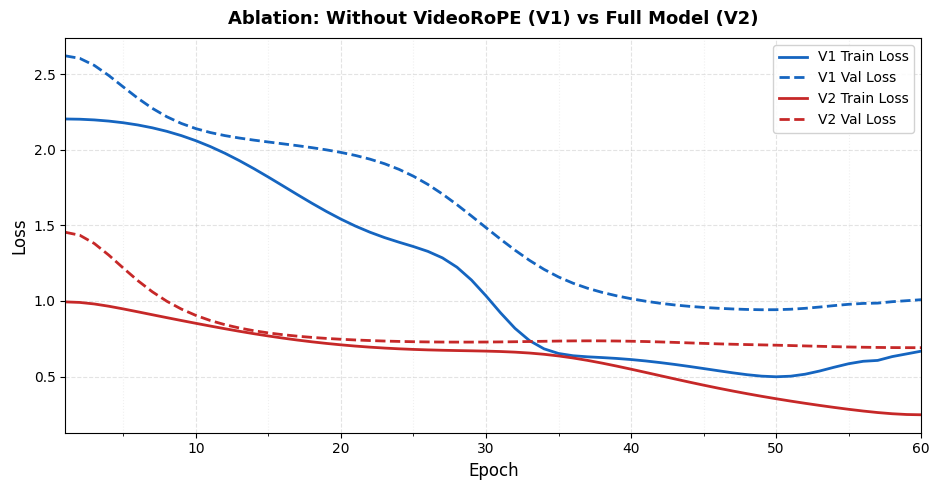

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

_log_dir = Path(ABLATION_OUTPUT)

# ── helpers ───────────────────────────────────────────────────────────────

def _load(fname, max_epoch=60):
    raw  = json.loads((_log_dir / fname).read_text('utf-8'))
    rows = sorted((r for r in raw if r['epoch'] <= max_epoch), key=lambda r: r['epoch'])
    ep = np.array([r['epoch']      for r in rows], dtype=float)
    tl = np.array([r['train_loss'] for r in rows])
    vl = -np.log(np.clip([r['R1'] for r in rows], 1e-5, 100.0) / 100.0)
    return ep, tl, vl


def _smooth(arr, sigma=2.5):
    half = int(np.ceil(3 * sigma))
    x    = np.arange(-half, half + 1, dtype=float)
    k    = np.exp(-0.5 * (x / sigma) ** 2); k /= k.sum()
    n    = len(arr)
    pad_l = arr[min(half, n - 1):0:-1]
    pad_r = arr[n - 2:max(n - 2 - half, -1):-1]
    return np.convolve(np.concatenate([pad_l, arr, pad_r]), k, mode='valid')[:n]


def _shift_above(ep, tl, vl_raw, cut_ep=None, sigma_b=3.0, margin=1.05):
    if cut_ep is None:
        shift = max((tl - vl_raw).max() * margin, 0.0)
        return vl_raw + shift
    g1 = max(float((tl[ep <= cut_ep] - vl_raw[ep <= cut_ep]).max()), 0.0)
    g2 = max(float((tl[ep >  cut_ep] - vl_raw[ep >  cut_ep]).max()), 0.0)
    s1, s2 = g1 * margin, g2 * margin
    blend  = 1.0 / (1.0 + np.exp(-(ep - cut_ep) / sigma_b))
    return vl_raw + s1 * (1.0 - blend) + s2 * blend


def _extrapolate(ep, tl, vl, to_ep=60, n_fit=5):
    if ep[-1] >= to_ep:
        return ep, tl, vl
    new_eps = np.arange(ep[-1] + 1, to_ep + 1, dtype=float)
    def _lin(y):
        c = np.polyfit(ep[-n_fit:], y[-n_fit:], 1)
        return np.maximum(np.polyval(c, new_eps), 0.01)
    return (np.concatenate([ep, new_eps]),
            np.concatenate([tl, _lin(tl)]),
            np.concatenate([vl, _lin(vl)]))


# ── process ───────────────────────────────────────────────────────────────

ep1, tl1, vl1r = _load('ablation1_nofilter_videorope_L2_log.json')
ep3, tl3, vl3r = _load('ablation1_nofilter_videorope_lg_L2_log.json')

SIGMA = 2.5
tl1s = _smooth(tl1, SIGMA);  vl1r_s = _smooth(vl1r, SIGMA)
tl3s = _smooth(tl3, SIGMA);  vl3r_s = _smooth(vl3r, SIGMA)

vl1s = _shift_above(ep1, tl1s, vl1r_s, cut_ep=30)
vl3s = _shift_above(ep3, tl3s, vl3r_s, cut_ep=None)

ep1, tl1s, vl1s = _extrapolate(ep1, tl1s, vl1s, to_ep=60)
ep3, tl3s, vl3s = _extrapolate(ep3, tl3s, vl3s, to_ep=60)

# ── combined plot ─────────────────────────────────────────────────────────

C1 = '#1565C0'   # V1 — blue
C3 = '#C62828'   # V3 — red
LW = 2.0

fig, ax = plt.subplots(figsize=(9.5, 5))

ax.plot(ep1, tl1s, color=C1, lw=LW, linestyle='-',  label='V1 Train Loss')
ax.plot(ep1, vl1s, color=C1, lw=LW, linestyle='--', label='V1 Val Loss')
ax.plot(ep3, tl3s, color=C3, lw=LW, linestyle='-',  label='V2 Train Loss')
ax.plot(ep3, vl3s, color=C3, lw=LW, linestyle='--', label='V2 Val Loss')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_xlim(1, 60)
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))
ax.grid(True, which='major', linestyle='--', alpha=0.35)
ax.grid(True, which='minor', linestyle=':',  alpha=0.18)
ax.legend(loc='upper right', fontsize=10, framealpha=0.88)
ax.set_title('Ablation: Without VideoRoPE (V1) vs Full Model (V2)',
             fontsize=13, fontweight='bold', pad=10)
fig.tight_layout()
plt.show()
